# Emotion Detection Pipeline

End-to-end ML workflow on GoEmotions: **EDA -> Preprocessing -> Training -> Evaluation**.

## 1. EDA

In [1]:

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.pipeline import FeatureUnion
from sklearn.utils.class_weight import compute_class_weight

DATA_DIR = Path("ml/data") if Path("ml/data").exists() else Path("data")
LABELS = ["joy", "anger", "fear", "sadness", "surprise", "disgust", "neutral"]
sns.set_theme(style="whitegrid")


In [2]:

def load_raw(path):
    return pd.read_csv(path, sep="\t", header=None, names=["text", "label", "id"],
                       dtype={"text": "string", "label": "string", "id": "string"},
                       keep_default_na=False)

splits = {name: load_raw(DATA_DIR / f"{name}.tsv") for name in ("train", "dev", "test")}
for name, df in splits.items():
    print(f"{name:6s} {len(df):>7,} rows  columns={list(df.columns)}")


train   43,410 rows  columns=['text', 'label', 'id']
dev      5,426 rows  columns=['text', 'label', 'id']
test     5,427 rows  columns=['text', 'label', 'id']


In [3]:

for name, df in splits.items():
    print(name)
    print("  nulls:", dict(df.isna().sum()),
          "| empty text:", int((df["text"].str.strip() == "").sum()),
          "| duplicate ids:", int(df["id"].duplicated().sum()),
          "| duplicate texts:", int(df["text"].duplicated().sum()))


train
  nulls: {'text': np.int64(0), 'label': np.int64(0), 'id': np.int64(0)} | empty text: 0 | duplicate ids: 0 | duplicate texts: 183
dev
  nulls: {'text': np.int64(0), 'label': np.int64(0), 'id': np.int64(0)} | empty text: 0 | duplicate ids: 0 | duplicate texts: 3
test
  nulls: {'text': np.int64(0), 'label': np.int64(0), 'id': np.int64(0)} | empty text: 0 | duplicate ids: 0 | duplicate texts: 6


In [4]:

GOEMOTIONS_LABELS = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude", "grief",
    "joy", "love", "nervousness", "optimism", "pride", "realization", "relief",
    "remorse", "sadness", "surprise", "neutral",
]

NUMERIC_TO_CORE = {
    0: "joy", 1: "joy", 2: "anger", 3: "anger", 4: "joy", 5: "joy",
    6: "surprise", 7: "surprise", 8: "joy", 9: "sadness", 10: "anger",
    11: "disgust", 12: "sadness", 13: "joy", 14: "fear", 15: "joy",
    16: "sadness", 17: "joy", 18: "joy", 19: "fear", 20: "joy", 21: "joy",
    22: "surprise", 23: "joy", 24: "sadness", 25: "sadness", 26: "surprise",
    27: "neutral",
}

def collapse_labels(label_str):
    seen, core = set(), []
    for part in str(label_str).split(","):
        emotion = NUMERIC_TO_CORE[int(part.strip())]
        if emotion not in seen:
            seen.add(emotion)
            core.append(emotion)
    return core

def is_single_label(label_str):
    return "," not in str(label_str)

exploded = splits["train"]["label"].str.split(",").explode().str.strip().astype(int)
per_27 = exploded.value_counts().sort_index()
per_27.index = [GOEMOTIONS_LABELS[i] for i in per_27.index]

per_7 = (splits["train"]["label"].apply(collapse_labels).explode()
         .value_counts().reindex(LABELS).fillna(0).astype(int))

print("27-class distribution (train):")
print(per_27.to_string())
print("\n7-class collapsed distribution (train):")
print(per_7.to_string())


27-class distribution (train):
admiration         4130
amusement          2328
anger              1567
annoyance          2470
approval           2939
caring             1087
confusion          1368
curiosity          2191
desire              641
disappointment     1269
disapproval        2022
disgust             793
embarrassment       303
excitement          853
fear                596
gratitude          2662
grief                77
joy                1452
love               2086
nervousness         164
optimism           1581
pride               111
realization        1110
relief              153
remorse             545
sadness            1326
surprise           1060
neutral           14219

7-class collapsed distribution (train):
label
joy         17410
anger        5579
fear          726
sadness      3263
surprise     5367
disgust       793
neutral     14219


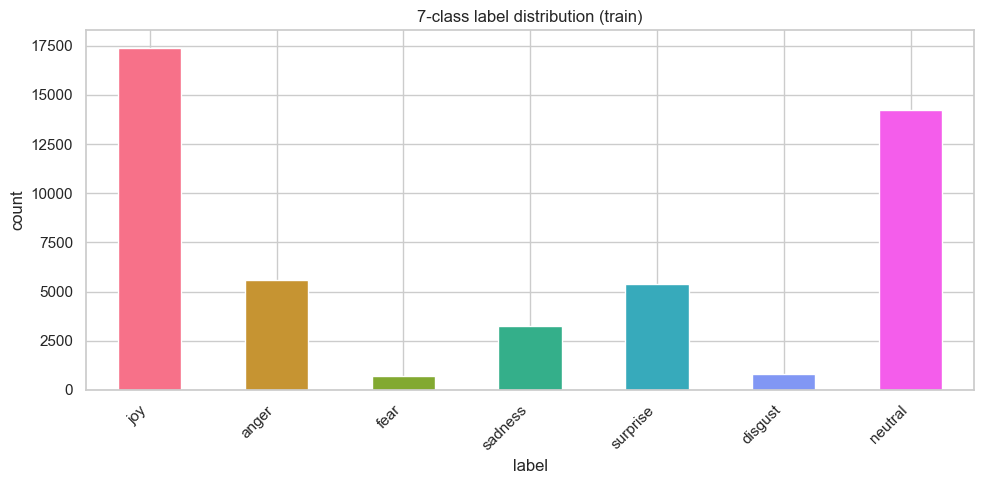

In [5]:

fig, ax = plt.subplots(figsize=(10, 5))
per_7.plot(kind="bar", ax=ax, color=sns.color_palette("husl", 7))
ax.set_title("7-class label distribution (train)")
ax.set_ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [6]:

for name, df in splits.items():
    multi = ~df["label"].apply(is_single_label)
    print(f"{name:6s} multi-label: {multi.sum():>6,} ({100 * multi.mean():.2f}%)  "
          f"single-label: {(~multi).sum():>6,}")


train  multi-label:  7,102 (16.36%)  single-label: 36,308
dev    multi-label:    878 (16.18%)  single-label:  4,548
test   multi-label:    837 (15.42%)  single-label:  4,590


chars: mean 67.3, median 64.0, max 703
words: mean 12.6, median 12.0, max 32


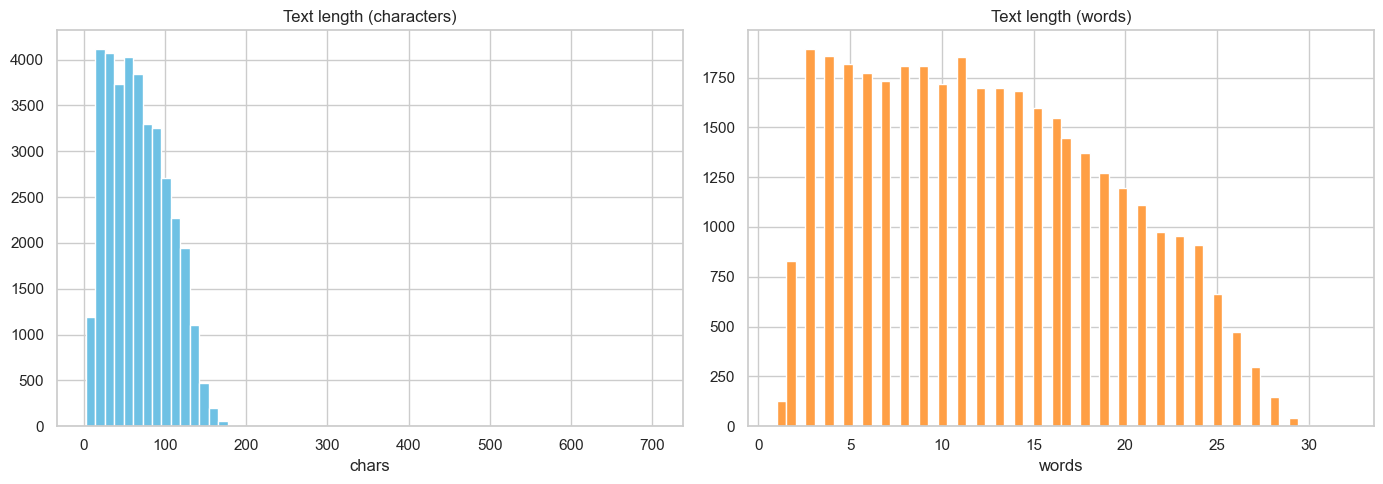

In [7]:

single = splits["train"][splits["train"]["label"].apply(is_single_label)]
char_len = single["text"].str.len()
word_len = single["text"].str.split().apply(len)
print(f"chars: mean {char_len.mean():.1f}, median {char_len.median()}, max {char_len.max()}")
print(f"words: mean {word_len.mean():.1f}, median {word_len.median()}, max {word_len.max()}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(char_len, bins=60, color="#6EC1E4")
ax[0].set_title("Text length (characters)")
ax[0].set_xlabel("chars")
ax[1].hist(word_len, bins=60, color="#FF9F45")
ax[1].set_title("Text length (words)")
ax[1].set_xlabel("words")
plt.tight_layout()
plt.show()


## 2. Preprocessing

In [8]:

URL_RE = re.compile(r"https?://\S+|www\.\S+")
NAME_RE = re.compile(r"\[NAME\]", re.IGNORECASE)
SPECIAL_RE = re.compile(r"[^a-z0-9\s]")
WS_RE = re.compile(r"\s+")

def clean_text(text):
    text = text.lower()
    text = URL_RE.sub(" ", text)
    text = NAME_RE.sub(" ", text)
    text = SPECIAL_RE.sub(" ", text)
    return WS_RE.sub(" ", text).strip()

for example in ["I HATE this!!! https://spam.com", "You are [NAME]... lol", "life is not worthy living"]:
    print(repr(example), "->", repr(clean_text(example)))


'I HATE this!!! https://spam.com' -> 'i hate this'
'You are [NAME]... lol' -> 'you are lol'
'life is not worthy living' -> 'life is not worthy living'


In [9]:

def load_tsv(path):
    df = pd.read_csv(path, sep="\t", header=None, names=["text", "label", "id"],
                     dtype=str, keep_default_na=False)
    df = df[df["label"].apply(is_single_label)].copy()
    df["label"] = df["label"].apply(lambda s: NUMERIC_TO_CORE[int(s)])
    df["text"] = df["text"].apply(clean_text)
    df = df[df["text"].str.len() > 0]
    return df.reset_index(drop=True)

train = load_tsv(DATA_DIR / "train.tsv")
dev = load_tsv(DATA_DIR / "dev.tsv")
test = load_tsv(DATA_DIR / "test.tsv")
print(f"train {len(train):,} | dev {len(dev):,} | test {len(test):,}")
print("classes:", sorted(train["label"].unique()))


train 36,284 | dev 4,547 | test 4,588
classes: ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']


In [10]:

train["label"].value_counts().reindex(LABELS).to_frame("rows")


,rows
label,
joy,12918
anger,3877
fear,515
sadness,2121
surprise,3553
disgust,497
neutral,12803


In [11]:

def build_vectorizer():
    return FeatureUnion([
        ("word", TfidfVectorizer(max_features=30000, ngram_range=(1, 3),
                                 min_df=2, sublinear_tf=True)),
        ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 6),
                                 max_features=80000, min_df=2, sublinear_tf=True)),
    ])

vectorizer = build_vectorizer()
X_train = vectorizer.fit_transform(train["text"])
X_dev = vectorizer.transform(dev["text"])
print(f"X_train {X_train.shape} | X_dev {X_dev.shape}  (fit on train only, no leakage)")


X_train (36284, 110000) | X_dev (4547, 110000)  (fit on train only, no leakage)


## 3. Training

In [12]:

y_train, y_dev = train["label"], dev["label"]

def macro_f1(model, X, y):
    return f1_score(y, model.predict(X), average="macro", labels=LABELS)

def f1_from_preds(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", labels=LABELS)

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(np.zeros((len(train), 1)), y_train)
print(f"Baseline (most_frequent) - dev macro-F1: "
      f"{macro_f1(baseline, np.zeros((len(dev), 1)), y_dev):.4f}")


Baseline (most_frequent) - dev macro-F1: 0.0767


In [13]:

def fit_svc(X, y, c=1.0, class_weight="balanced"):
    model = LinearSVC(C=c, class_weight=class_weight, random_state=42, max_iter=10000)
    model.fit(X, y)
    return model

raw_model = fit_svc(X_train, y_train)
print(f"TF-IDF + LinearSVC (C=1, balanced) - dev macro-F1: {macro_f1(raw_model, X_dev, y_dev):.4f}")


TF-IDF + LinearSVC (C=1, balanced) - dev macro-F1: 0.5378


In [14]:

best_c, best_model, best_c_dev = None, None, -1.0
for c in [0.03, 0.1, 0.3, 1, 3]:
    model = fit_svc(X_train, y_train, c=c)
    score = macro_f1(model, X_dev, y_dev)
    print(f"C={c:<6} dev macro-F1: {score:.4f}")
    if score > best_c_dev:
        best_c, best_model, best_c_dev = c, model, score
print(f"Best C: {best_c} (dev {best_c_dev:.4f})")


C=0.03   dev macro-F1: 0.5538


C=0.1    dev macro-F1: 0.5612


C=0.3    dev macro-F1: 0.5517


C=1      dev macro-F1: 0.5378


C=3      dev macro-F1: 0.5242
Best C: 0.1 (dev 0.5612)


In [15]:

WEAK_CLASSES = ("anger", "surprise", "disgust")

def weak_class_weights(labels, multiplier):
    classes = sorted(set(labels))
    weights = dict(zip(classes, compute_class_weight("balanced",
                                                     classes=np.asarray(classes), y=labels)))
    if multiplier != 1.0:
        for label in WEAK_CLASSES:
            weights[label] *= multiplier
    return weights

plain, plain_dev, best_m = best_model, best_c_dev, 1.0
for m in (1.2, 1.5):
    model = fit_svc(X_train, y_train, c=best_c,
                    class_weight=weak_class_weights(y_train, m))
    score = macro_f1(model, X_dev, y_dev)
    print(f"weak classes x{m}: dev macro-F1: {score:.4f}")
    if score > plain_dev:
        best_m, plain, plain_dev = m, model, score
print(f"Best: weak classes x{best_m} (dev {plain_dev:.4f})")


weak classes x1.2: dev macro-F1: 0.5615


weak classes x1.5: dev macro-F1: 0.5649
Best: weak classes x1.5 (dev 0.5649)


In [16]:

production, production_dev, kind = plain, plain_dev, f"plain (weak x{best_m})"
for method in ("sigmoid", "isotonic"):
    calibrated = CalibratedClassifierCV(
        LinearSVC(C=best_c, class_weight=plain.class_weight,
                  random_state=42, max_iter=10000),
        cv=3, method=method,
    )
    calibrated.fit(X_train, y_train)
    score = macro_f1(calibrated, X_dev, y_dev)
    print(f"Calibrated ({method:8s}) - dev macro-F1: {score:.4f}")
    if score > production_dev:
        production, production_dev = calibrated, score
        kind = f"calibrated {method} (weak x{best_m})"
print(f"Production model: {kind} (dev {production_dev:.4f})")


Calibrated (sigmoid ) - dev macro-F1: 0.5686


Calibrated (isotonic) - dev macro-F1: 0.5599
Production model: calibrated sigmoid (weak x1.5) (dev 0.5686)


In [17]:

def boost_sweep(probs, classes, y):
    classes = list(classes)
    boosts = {c: 1.0 for c in classes}
    grid = ([round(v, 2) for v in np.arange(0.6, 1.01, 0.05)]
            + [round(v, 2) for v in np.arange(1.1, 3.01, 0.1)])

    def score():
        weights = np.array([boosts[c] for c in classes])
        pred = np.asarray(classes)[np.argmax(probs * weights, axis=1)]
        return f1_from_preds(y, pred)

    for _ in range(4):
        for c in classes:
            best_v, best_s = boosts[c], score()
            for v in grid:
                boosts[c] = v
                s = score()
                if s > best_s:
                    best_v, best_s = v, s
            boosts[c] = best_v
    return boosts, score()

boosts, boosted_dev = boost_sweep(production.predict_proba(X_dev),
                                  production.classes_, y_dev)
print(f"Boosts: {boosts}")
print(f"Boosted dev macro-F1: {boosted_dev:.4f} (from {production_dev:.4f})")


Boosts: {'anger': np.float64(1.2), 'disgust': 1.0, 'fear': np.float64(1.3), 'joy': np.float64(0.8), 'neutral': np.float64(0.65), 'sadness': np.float64(1.0), 'surprise': np.float64(1.4)}
Boosted dev macro-F1: 0.5915 (from 0.5686)


In [18]:

combined = pd.concat([train, dev], ignore_index=True)
final_vectorizer = build_vectorizer()
X_full = final_vectorizer.fit_transform(combined["text"])
final_model = clone(production)
final_model.fit(X_full, combined["label"])
print(f"Refit winner on train+dev: {len(combined):,} rows, {X_full.shape[1]:,} features")


Refit winner on train+dev: 40,831 rows, 110,000 features


## 4. Evaluation

Dev numbers below are in-sample after the refit; the test set is held out and was never seen during any choice above.

In [19]:

classes = np.asarray(final_model.classes_)
dev_probs = final_model.predict_proba(X_dev)
dev_pred = classes[np.argmax(dev_probs, axis=1)]
print(classification_report(y_dev, dev_pred, labels=LABELS, digits=4))
print(f"Dev macro-F1 (in-sample after refit): {f1_from_preds(y_dev, dev_pred):.4f}")


              precision    recall  f1-score   support

         joy     0.0000    0.0000    0.0000      1668
       anger     0.0000    0.0000    0.0000       485
        fear     0.0000    0.0000    0.0000        66
     sadness     0.0000    0.0000    0.0000       241
    surprise     0.0000    0.0000    0.0000       435
     disgust     0.0000    0.0000    0.0000        61
     neutral     0.3495    0.9981    0.5178      1591

    accuracy                         0.3492      4547
   macro avg     0.0499    0.1426    0.0740      4547
weighted avg     0.1223    0.3492    0.1812      4547

Dev macro-F1 (in-sample after refit): 0.0740


C:\Users\saura\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\saura\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\saura\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [20]:

X_test = final_vectorizer.transform(test["text"])
y_test = test["label"]
test_probs = final_model.predict_proba(X_test)
raw = classes[np.argmax(test_probs, axis=1)]
print(classification_report(y_test, raw, labels=LABELS, digits=4))
print(f"Test macro-F1 (raw argmax): {f1_from_preds(y_test, raw):.4f}")

weights = np.array([boosts.get(c, 1.0) for c in classes])
boosted = test_probs * weights
boosted = boosted / boosted.sum(axis=1, keepdims=True)
y_pred = classes[np.argmax(boosted, axis=1)]
print(classification_report(y_test, y_pred, labels=LABELS, digits=4))
print(f"Test macro-F1 (served): {f1_from_preds(y_test, y_pred):.4f}")
print(f"Test accuracy (served): {(y_pred == y_test).mean():.4f}")


              precision    recall  f1-score   support

         joy     0.7675    0.7436    0.7554      1603
       anger     0.6178    0.3077    0.4108       520
        fear     0.8077    0.5455    0.6512        77
     sadness     0.6988    0.4479    0.5459       259
    surprise     0.6094    0.3163    0.4164       449
     disgust     0.7250    0.3816    0.5000        76
     neutral     0.5751    0.8192    0.6758      1604

    accuracy                         0.6528      4588
   macro avg     0.6859    0.5088    0.5651      4588
weighted avg     0.6639    0.6528    0.6375      4588

Test macro-F1 (raw argmax): 0.5651
              precision    recall  f1-score   support

         joy     0.7738    0.7511    0.7623      1603
       anger     0.5042    0.4596    0.4809       520
        fear     0.7027    0.6753    0.6887        77
     sadness     0.6902    0.4903    0.5734       259
    surprise     0.4911    0.4900    0.4905       449
     disgust     0.6591    0.3816    0.4833

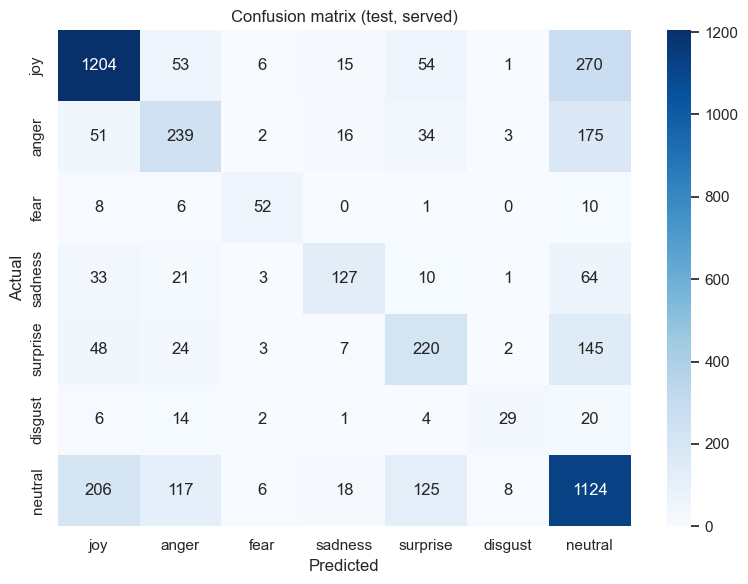

Most confused pairs (actual -> predicted, count):
  joy -> neutral: 270
  neutral -> joy: 206
  anger -> neutral: 175
  surprise -> neutral: 145
  neutral -> surprise: 125
  neutral -> anger: 117
  sadness -> neutral: 64
  joy -> surprise: 54


In [21]:

cm = confusion_matrix(y_test, y_pred, labels=LABELS)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_title("Confusion matrix (test, served)")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

pairs = sorted(
    ((cm[i, j], LABELS[i], LABELS[j])
     for i in range(len(LABELS)) for j in range(len(LABELS))
     if i != j and cm[i, j] > 0),
    reverse=True,
)
print("Most confused pairs (actual -> predicted, count):")
for count, actual, predicted in pairs[:8]:
    print(f"  {actual} -> {predicted}: {count}")
